# Imports

In [2]:
from qiskit.circuit.library import TwoLocal
from qiskit.result import QuasiDistribution
from qiskit.primitives import StatevectorSampler
from qiskit_algorithms import NumPyMinimumEigensolver, QAOA, SamplingVQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit_finance.applications.optimization import PortfolioOptimization
from qiskit_finance.data_providers import RandomDataProvider
from qiskit_optimization.algorithms import MinimumEigenOptimizer
import numpy as np
import matplotlib.pyplot as plt
import datetime
from qiskit_finance.data_providers import *
from qiskit_finance import QiskitFinanceError

In [3]:
# set number of assets (= number of qubits)
num_assets = 4
seed = 42

# Generate expected return and covariance matrix from (random) time-series
stocks = [("TICKER%s" % i) for i in range(num_assets)]
data = YahooDataProvider(
        tickers=["MSFT", "AAPL", "GOOG", "NVDA"],
        start=datetime.datetime(2021, 1, 1),
        end=datetime.datetime(2021, 12, 31),
    )
data.run()
mu = data.get_period_return_mean_vector()
sigma = data.get_period_return_covariance_matrix()

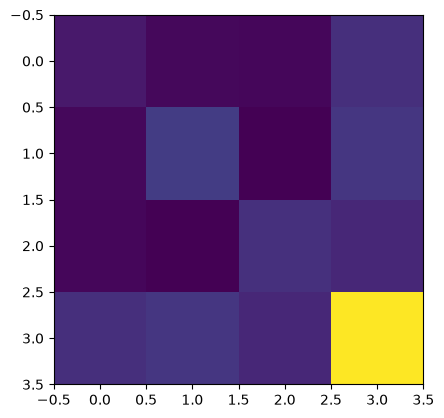

In [4]:
plt.imshow(sigma, interpolation="nearest")
plt.show()

# Using SamplingVQE

In [5]:
q = 0.5  # set risk factor
budget = num_assets // 2  # set budget
penalty = num_assets  # set parameter to scale the budget penalty term

portfolio = PortfolioOptimization(
    expected_returns=mu, covariances=sigma, risk_factor=q, budget=budget
)
qp = portfolio.to_quadratic_program()
qp

<QuadraticProgram: minimize 8.731298409604327e-05*x_0^2 + 0.000141669156927873..., 4 variables, 1 constraints, 'Portfolio optimization'>

In [6]:
def print_result(result):
    selection = result.x
    value = result.fval
    print("Optimal: selection {}, value {:.4f}".format(selection, value))

    eigenstate = result.min_eigen_solver_result.eigenstate
    probabilities = (
        eigenstate.binary_probabilities()
        if isinstance(eigenstate, QuasiDistribution)
        else {k: np.abs(v) ** 2 for k, v in eigenstate.to_dict().items()}
    )
    print("\n----------------- Full result ---------------------")
    print("selection\tvalue\t\tprobability")
    print("---------------------------------------------------")
    probabilities = sorted(probabilities.items(), key=lambda x: x[1], reverse=True)

    for k, v in probabilities:
        x = np.array([int(i) for i in list(reversed(k))])
        value = portfolio.to_quadratic_program().objective.evaluate(x)
        print("%10s\t%.4f\t\t%.4f" % (x, value, v))

In [7]:
exact_mes = NumPyMinimumEigensolver()
exact_eigensolver = MinimumEigenOptimizer(exact_mes)

result = exact_eigensolver.solve(qp)

print_result(result)

Optimal: selection [0. 0. 1. 1.], value -0.0052

----------------- Full result ---------------------
selection	value		probability
---------------------------------------------------
 [0 0 1 1]	-0.0052		1.0000


In [8]:
from qiskit_algorithms.utils import algorithm_globals

algorithm_globals.random_seed = 1234

cobyla = COBYLA()
cobyla.set_options(maxiter=500)
ry = TwoLocal(num_assets, "ry", "cz", reps=3, entanglement="full")
svqe_mes = SamplingVQE(
    sampler=StatevectorSampler(),
    ansatz=ry,
    optimizer=cobyla
)
svqe = MinimumEigenOptimizer(svqe_mes)
result = svqe.solve(qp)

C:\Users\g.melis\AppData\Local\Temp\ipykernel_30972\431538109.py:7: DeprecationWarning: The class ``qiskit.circuit.library.n_local.two_local.TwoLocal`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.n_local instead.
  ry = TwoLocal(num_assets, "ry", "cz", reps=3, entanglement="full")


In [9]:
import pandas as pd
import numpy as np

# Solution optimale
print("=" * 60)
print("OPTIMAL PORTFOLIO")
print("=" * 60)
print(f"Selection : {result.x}")
print(f"Objective : {result.fval:.6f}")

# Distribution complète
probabilities = result.min_eigen_solver_result.eigenstate

rows = []

for bitstring, prob in probabilities.items():

    x = np.array([int(i) for i in reversed(bitstring)])

    objective_value = (
        portfolio
        .to_quadratic_program()
        .objective
        .evaluate(x)
    )

    rows.append({
        "Bitstring": bitstring,
        "Selection": x.tolist(),
        "Objective": objective_value,
        "Probability": prob
    })

df = pd.DataFrame(rows)

# Trier par probabilité décroissante
df = df.sort_values(
    by="Probability",
    ascending=False
).reset_index(drop=True)

print("\n")
print("=" * 60)
print("ALL MEASURED PORTFOLIOS")
print("=" * 60)

display(df)

OPTIMAL PORTFOLIO
Selection : [0. 0. 1. 1.]
Objective : -0.005154


ALL MEASURED PORTFOLIOS


,Bitstring,Selection,Objective,Probability
0,1001,"[1, 0, 0, 1]",-0.004847,0.618164
1,0011,"[1, 1, 0, 0]",-0.002973,0.208984
2,0001,"[1, 0, 0, 0]",-0.001810,0.115234
3,0000,"[0, 0, 0, 0]",0.000000,0.015625
4,0110,"[0, 1, 1, 0]",-0.003275,0.014648
5,0101,"[1, 0, 1, 0]",-0.003768,0.014648
6,1011,"[1, 1, 0, 1]",-0.005774,0.004883
7,1100,"[0, 0, 1, 1]",-0.005154,0.003906
8,1101,"[1, 0, 1, 1]",-0.006602,0.003906


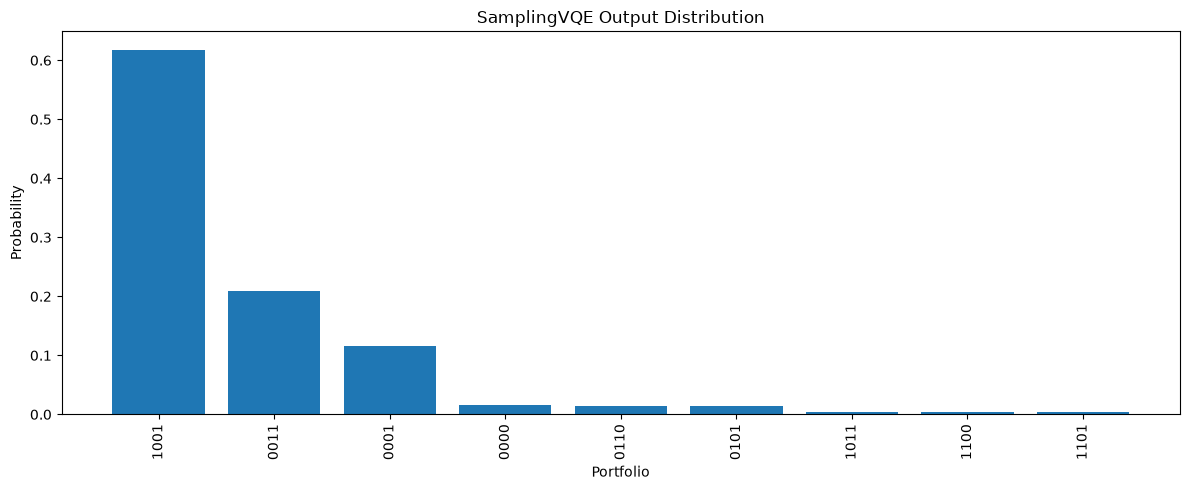

In [10]:
plt.figure(figsize=(12,5))
plt.bar(df["Bitstring"], df["Probability"])
plt.xticks(rotation=90)
plt.ylabel("Probability")
plt.xlabel("Portfolio")
plt.title("SamplingVQE Output Distribution")
plt.tight_layout()
plt.show()

# Using QAOA

In [11]:
algorithm_globals.random_seed = 1234

cobyla = COBYLA()
cobyla.set_options(maxiter=250)
qaoa_mes = QAOA(sampler=StatevectorSampler(), optimizer=cobyla, reps=3)
qaoa = MinimumEigenOptimizer(qaoa_mes)
result = qaoa.solve(qp)


c:\Users\g.melis\OneDrive - AXIS ALTERNATIVES\Bureau\Quantum pricing\Code\.venv\Lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
c:\Users\g.melis\OneDrive - AXIS ALTERNATIVES\Bureau\Quantum pricing\Code\.venv\Lib\site-packages\scipy\sparse\linalg\_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
c:\Users\g.melis\OneDrive - AXIS ALTERNATIVES\Bureau\Quantum pricing\Code\.venv\Lib\site-packages\scipy\sparse\_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


In [12]:
print("=" * 60)
print("QAOA OPTIMAL PORTFOLIO")
print("=" * 60)
print(f"Selection : {result.x}")
print(f"Objective : {result.fval:.6f}")

QAOA OPTIMAL PORTFOLIO
Selection : [0. 0. 1. 1.]
Objective : -0.005154


In [13]:
probabilities = result.min_eigen_solver_result.eigenstate

rows = []

for bitstring, prob in probabilities.items():

    x = np.array([int(i) for i in reversed(bitstring)])

    objective_value = (
        portfolio
        .to_quadratic_program()
        .objective
        .evaluate(x)
    )

    rows.append({
        "Bitstring": bitstring,
        "Selection": x.tolist(),
        "Objective": objective_value,
        "Probability": prob
    })

df = pd.DataFrame(rows)

df = (
    df.sort_values(
        "Probability",
        ascending=False
    )
    .reset_index(drop=True)
)

In [14]:
print("\n")
print("=" * 60)
print("TOP 10 MOST PROBABLE PORTFOLIOS")
print("=" * 60)

display(df.head(10))



TOP 10 MOST PROBABLE PORTFOLIOS


,Bitstring,Selection,Objective,Probability
0,0011,"[1, 1, 0, 0]",-0.002973,0.177734
1,1010,"[0, 1, 0, 1]",-0.004327,0.170898
2,0110,"[0, 1, 1, 0]",-0.003275,0.169922
3,1100,"[0, 0, 1, 1]",-0.005154,0.166992
4,0101,"[1, 0, 1, 0]",-0.003768,0.152344
5,1001,"[1, 0, 0, 1]",-0.004847,0.150391
6,1111,"[1, 1, 1, 1]",-0.007400,0.006836
7,0000,"[0, 0, 0, 0]",0.000000,0.004883


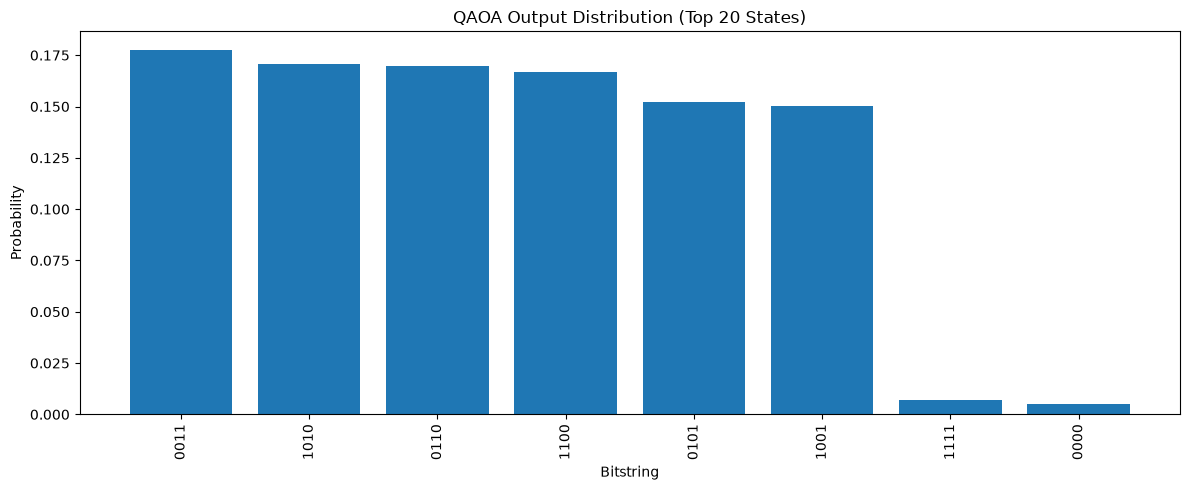

In [15]:
plt.figure(figsize=(12, 5))

plt.bar(
    df["Bitstring"].head(20),
    df["Probability"].head(20)
)

plt.xlabel("Bitstring")
plt.ylabel("Probability")
plt.title("QAOA Output Distribution (Top 20 States)")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

# Comparison of the two methods 

In [16]:
exact_mes = NumPyMinimumEigensolver()
exact = MinimumEigenOptimizer(exact_mes)

exact_result = exact.solve(qp)

print("Exact optimum :", exact_result.fval)
print("QAOA optimum  :", result.fval)

Exact optimum : -0.005153768621557196
QAOA optimum  : -0.005153768621557196
